In [4]:
# Utilisation du chemin relatif de data
chemin_donnees = '../data/enron_spam_data.csv'

 1 : Importation et chargement


In [ ]:
#Importation les bibliothéques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
#Chargement le fichier.csv 'enron_spam_data.csv'
df_enron = pd.read_csv(chemin_donnees)
# Afficher les 5 premières lignes
df_enron.head()

,Unnamed: 0,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


2 : Informations de base et qualité des données

In [6]:
# Taille du dataset
print(f"Forme du dataset : {df_enron.shape}")

Forme du dataset : (33716, 5)


In [7]:
# Types de colonnes et valeurs manquantes
print(df_enron.info())

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  33716 non-null  int64
 1   Subject     33716 non-null  str  
 2   Message     33664 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB
None


In [8]:
# Vérification précise des valeurs nulles
print("\nValeurs manquantes par colonne :")
print(df_enron.isnull().sum())


Valeurs manquantes par colonne :
Unnamed: 0     0
Subject        0
Message       52
Spam/Ham       0
Date           0
dtype: int64


In [9]:
# Vérification des doublons
print(f"\nNombre de lignes dupliquées : {df_enron.duplicated().sum()}")


Nombre de lignes dupliquées : 0


3:nettoyage des données

In [ ]:
#  Remplissage des valeurs nulles dans la colonne 'Message'
df_enron['Message'] = df_enron['Message'].fillna('')
# Vérification

print(df_enron.isnull().sum())

Unnamed: 0    0
Subject       0
Message       0
Spam/Ham      0
Date          0
dtype: int64


In [14]:
# Fusion des colonnes 'Subject' et 'Message' dans une nouvelle colonne 'clean_text'
# On ajoute un espace entre les deux pour éviter que le dernier mot du sujet et le premier du message ne se collent.
df_enron['clean_text'] = df_enron['Subject'] + " " + df_enron['Message']
#Vérification
df_enron.head()


,Unnamed: 0,Subject,Message,Spam/Ham,Date,clean_text
0,0,christmas tree farm pictures,,ham,1999-12-10,christmas tree farm pictures
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,"vastar resources , inc . gary , production fro..."
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,calpine daily gas nomination - calpine daily g...
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,re : issue fyi - see note below - already done...
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,meter 7268 nov allocation fyi .\n- - - - - - -...


In [15]:
#Suppression des colonnes inutiles
# On supprime 'Date', les colonnes 'Unnamed' et aussi les anciennes colonnes 'Subject'/'Message'
# car tout est maintenant dans 'clean_text'
colonnes_inutiles = ['Date' , 'Unnamed: 0' , 'Subject' , 'Message']
df_enron = df_enron.drop(columns=colonnes_inutiles, errors='ignore')
#Vérification
df_enron.head()

,Spam/Ham,clean_text
0,ham,christmas tree farm pictures
1,ham,"vastar resources , inc . gary , production fro..."
2,ham,calpine daily gas nomination - calpine daily g...
3,ham,re : issue fyi - see note below - already done...
4,ham,meter 7268 nov allocation fyi .\n- - - - - - -...


In [16]:
#Sauvegarde du nouveau dataset propre dans le dossier data
df_enron.to_csv('../data/enron_clean.csv', index=False)
print("✅ Nettoyage terminé !")
print(f"Nouveau fichier sauvegardé sous : '../data/enron_clean.csv'")
print(f"Colonnes finales : {df_enron.columns.tolist()}")
df_enron.head()

✅ Nettoyage terminé !
Nouveau fichier sauvegardé sous : '../data/enron_clean.csv'
Colonnes finales : ['Spam/Ham', 'clean_text']


,Spam/Ham,clean_text
0,ham,christmas tree farm pictures
1,ham,"vastar resources , inc . gary , production fro..."
2,ham,calpine daily gas nomination - calpine daily g...
3,ham,re : issue fyi - see note below - already done...
4,ham,meter 7268 nov allocation fyi .\n- - - - - - -...


4:Analyse spécifique au projet

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64


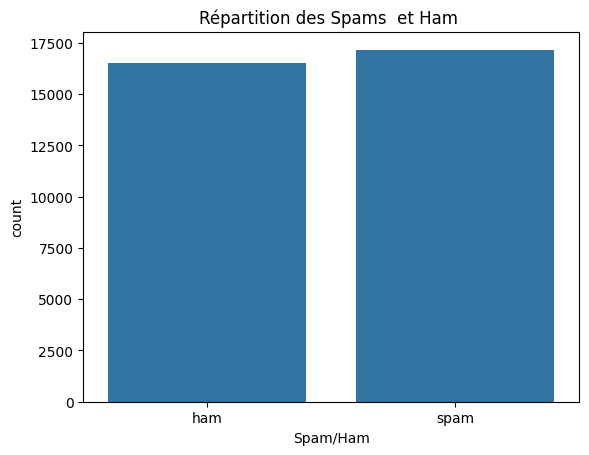

In [ ]:
# 1. Équilibre des classes (Est-ce qu'on a autant de spams que de non-spams ?)
print(df_enron['Spam/Ham'].value_counts())
sns.countplot(x='Spam/Ham', data=df_enron)
plt.title('Répartition des Spams  et Ham ')
# SAUVEGARDER 
plt.savefig('../resultats/01_repartition_spam_ham.png', bbox_inches='tight', dpi=300)
plt.show()



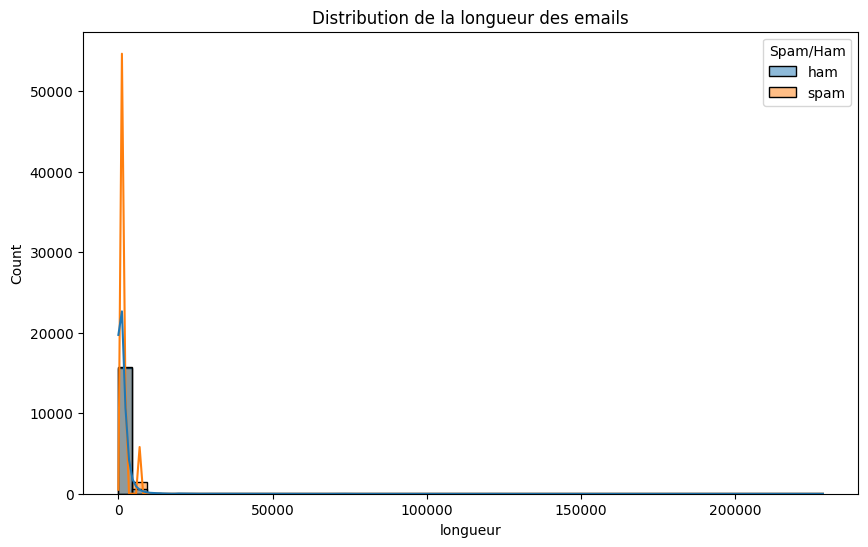

In [23]:
# 2. Longueur des messages (Souvent, les spams ont une longueur différente)
df_enron['longueur'] = df_enron['clean_text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_enron, x='longueur', hue='Spam/Ham', kde=True, bins=50)
plt.title('Distribution de la longueur des emails')
# Sauvegarde
plt.savefig('../resultats/02_distribution_longueur.png', bbox_inches='tight', dpi=300)
plt.show()